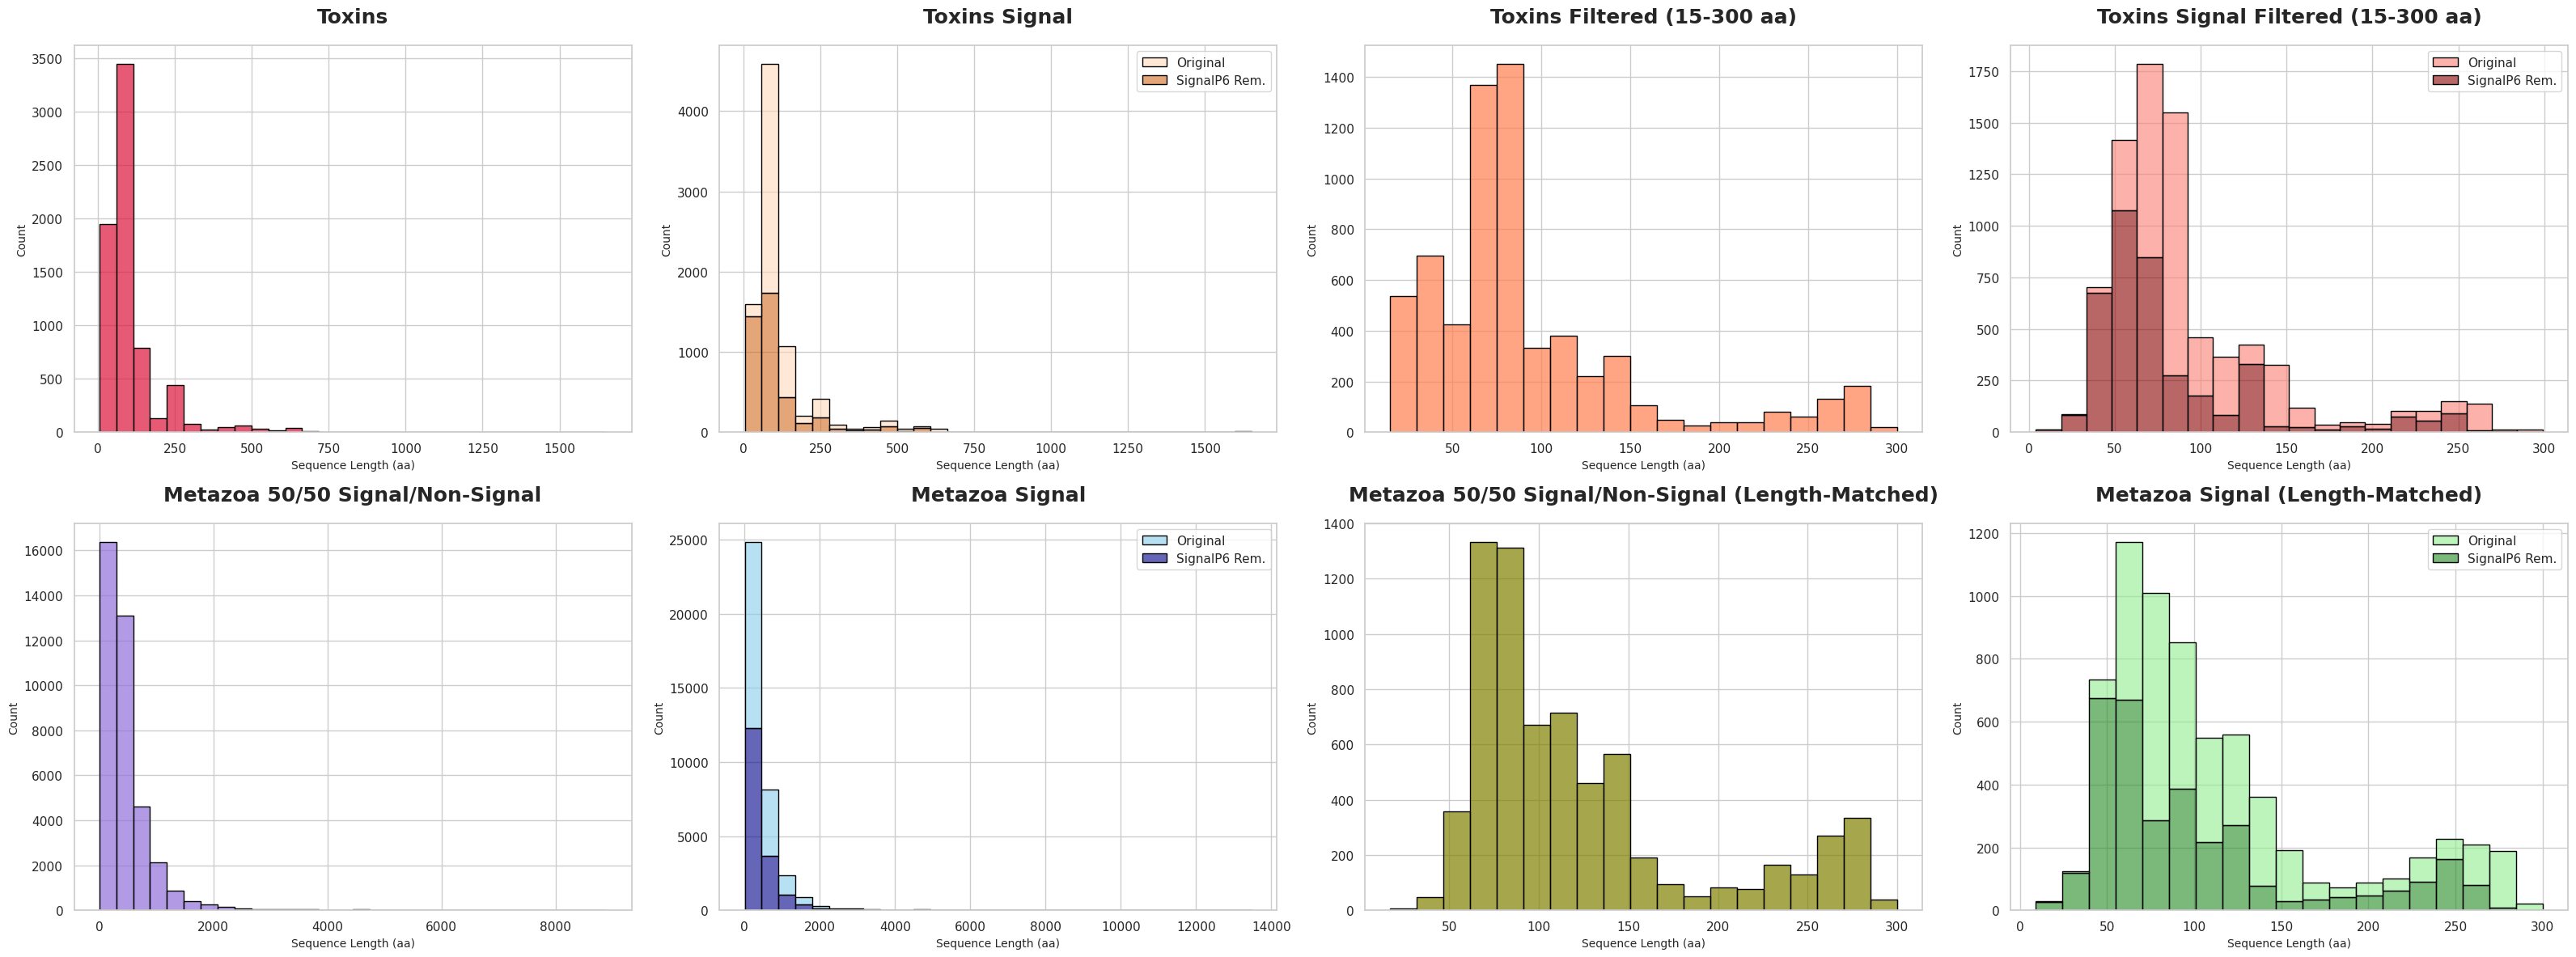

In [28]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Helper Function for FASTA Processing ---
def get_fasta_records(fasta_path):
    """Parses a FASTA file and returns a dictionary of {protein_id: sequence_length}."""
    if not os.path.exists(fasta_path):
        print(f"Warning: File not found at {fasta_path}. Skipping.")
        return {}
    records = {}
    current_id = None
    current_seq = []
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    records[current_id] = len("".join(current_seq))
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None:
            records[current_id] = len("".join(current_seq))
    return records

# --- 2. Load & Process Row 1 Datasets (TSV/CSV) ---
df_toxins = pd.read_csv("datasets/toxins.tsv", sep="\t")
df_signal = pd.read_csv("datasets/metazoa_nontoxin_signalpeptide5050.tsv", sep="\t")
df_nonsignal = pd.read_csv("datasets/metazoa_nontoxin_signalpeptide5050_lengthmatched.tsv", sep="\t")

lengths_toxins_full = df_toxins["Length"].dropna()
lengths_toxins_filtered = lengths_toxins_full[(lengths_toxins_full >= 15) & (lengths_toxins_full <= 300)]
lengths_signal = df_signal["Length"].dropna()
lengths_nonsignal = df_nonsignal["Length"].dropna()

# --- 3. Load & Process Row 2 Datasets (FASTA Pairs) ---
dict_sig_full = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide.fasta")
dict_sig_rem = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_signalp6_removed.fasta")
len_sig_full = list(dict_sig_full.values())
len_sig_rem = list(dict_sig_rem.values())

dict_matched_full = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_lengthmatched.fasta")
dict_matched_rem = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_lengthmatched_signalp6_removed.fasta")
len_matched_full = list(dict_matched_full.values())
len_matched_rem = list(dict_matched_rem.values())

dict_tox_full = get_fasta_records("datasets/toxins_signalpeptide.fasta")
dict_tox_rem = get_fasta_records("datasets/toxins_signalpeptide_signalp6_removed.fasta")
len_tox_full_unfiltered = list(dict_tox_full.values())
len_tox_rem_unfiltered = list(dict_tox_rem.values())

filtered_tox_full = {pid: length for pid, length in dict_tox_full.items() if 15 <= length <= 300}
len_tox_full_filtered = list(filtered_tox_full.values())
valid_toxin_ids = set(filtered_tox_full.keys())
len_tox_rem_filtered = [length for pid, length in dict_tox_rem.items() if pid in valid_toxin_ids]

# --- 4. Plotting Setup (2x4 Grid Layout) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(32, 12))

# Title configuration constant to avoid code repetition
TITLE_CONFIG = {"fontsize": 18, "fontweight": "bold", "pad": 20}

# ==========================================
# COL 0 & 1: UNFILTERED (bins=20)
# ==========================================

# [0, 0] Unfiltered: General Toxins Full (TSV)
sns.histplot(x=lengths_toxins_full, kde=False, color="crimson", bins=30, ax=axes[0, 0], edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Toxins", **TITLE_CONFIG)

# [0, 1] Unfiltered: FASTA Toxins Signal (Full Unfiltered)
sns.histplot(data={"Original": len_tox_full_unfiltered, "SignalP6 Rem.": len_tox_rem_unfiltered},
             multiple="stack", bins=30, kde=False, palette={"Original": "peachpuff", "SignalP6 Rem.": "chocolate"},
             edgecolor="black", alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Toxins Signal", **TITLE_CONFIG)

# [1, 0] Unfiltered: Metazoa 50/50 Signal (TSV)
sns.histplot(x=lengths_signal, kde=False, color="mediumpurple", bins=30, ax=axes[1, 0], edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Metazoa 50/50 Signal/Non-Signal", **TITLE_CONFIG)

# [1, 1] Unfiltered: FASTA Metazoa Signal (All Lengths)
sns.histplot(data={"Original": len_sig_full, "SignalP6 Rem.": len_sig_rem},
             multiple="stack", bins=30, kde=False, palette={"Original": "skyblue", "SignalP6 Rem.": "darkblue"},
             edgecolor="black", alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Metazoa Signal", **TITLE_CONFIG)

# ==========================================
# COL 2 & 3: FILTERED/MATCHED (binwidth=15)
# ==========================================

# [0, 2] Filtered: General Toxins Filtered (TSV)
sns.histplot(x=lengths_toxins_filtered, kde=False, color="coral", binwidth=15, ax=axes[0, 2], edgecolor="black", alpha=0.7)
axes[0, 2].set_title("Toxins Filtered (15-300 aa)", **TITLE_CONFIG)

# [0, 3] Filtered: FASTA Toxins Signal (Filtered 15-300 aa)
sns.histplot(data={"Original": len_tox_full_filtered, "SignalP6 Rem.": len_tox_rem_filtered},
             multiple="stack", binwidth=15, kde=False, palette={"Original": "salmon", "SignalP6 Rem.": "darkred"},
             edgecolor="black", alpha=0.6, ax=axes[0, 3])
axes[0, 3].set_title("Toxins Signal Filtered (15-300 aa)", **TITLE_CONFIG)

# [1, 2] Length-Matched: Metazoa 50/50 Non-Signal (TSV)
sns.histplot(x=lengths_nonsignal, kde=False, color="olive", binwidth=15, ax=axes[1, 2], edgecolor="black", alpha=0.7)
axes[1, 2].set_title("Metazoa 50/50 Signal/Non-Signal (Length-Matched)", **TITLE_CONFIG)

# [1, 3] Length-Matched: FASTA Metazoa Signal (Length-Matched)
sns.histplot(data={"Original": len_matched_full, "SignalP6 Rem.": len_matched_rem},
             multiple="stack", binwidth=15, kde=False, palette={"Original": "lightgreen", "SignalP6 Rem.": "forestgreen"},
             edgecolor="black", alpha=0.6, ax=axes[1, 3])
axes[1, 3].set_title("Metazoa Signal (Length-Matched)", **TITLE_CONFIG)

# Formatting labels for all axes
for ax in axes.flat:
    ax.set_xlabel("Sequence Length (aa)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

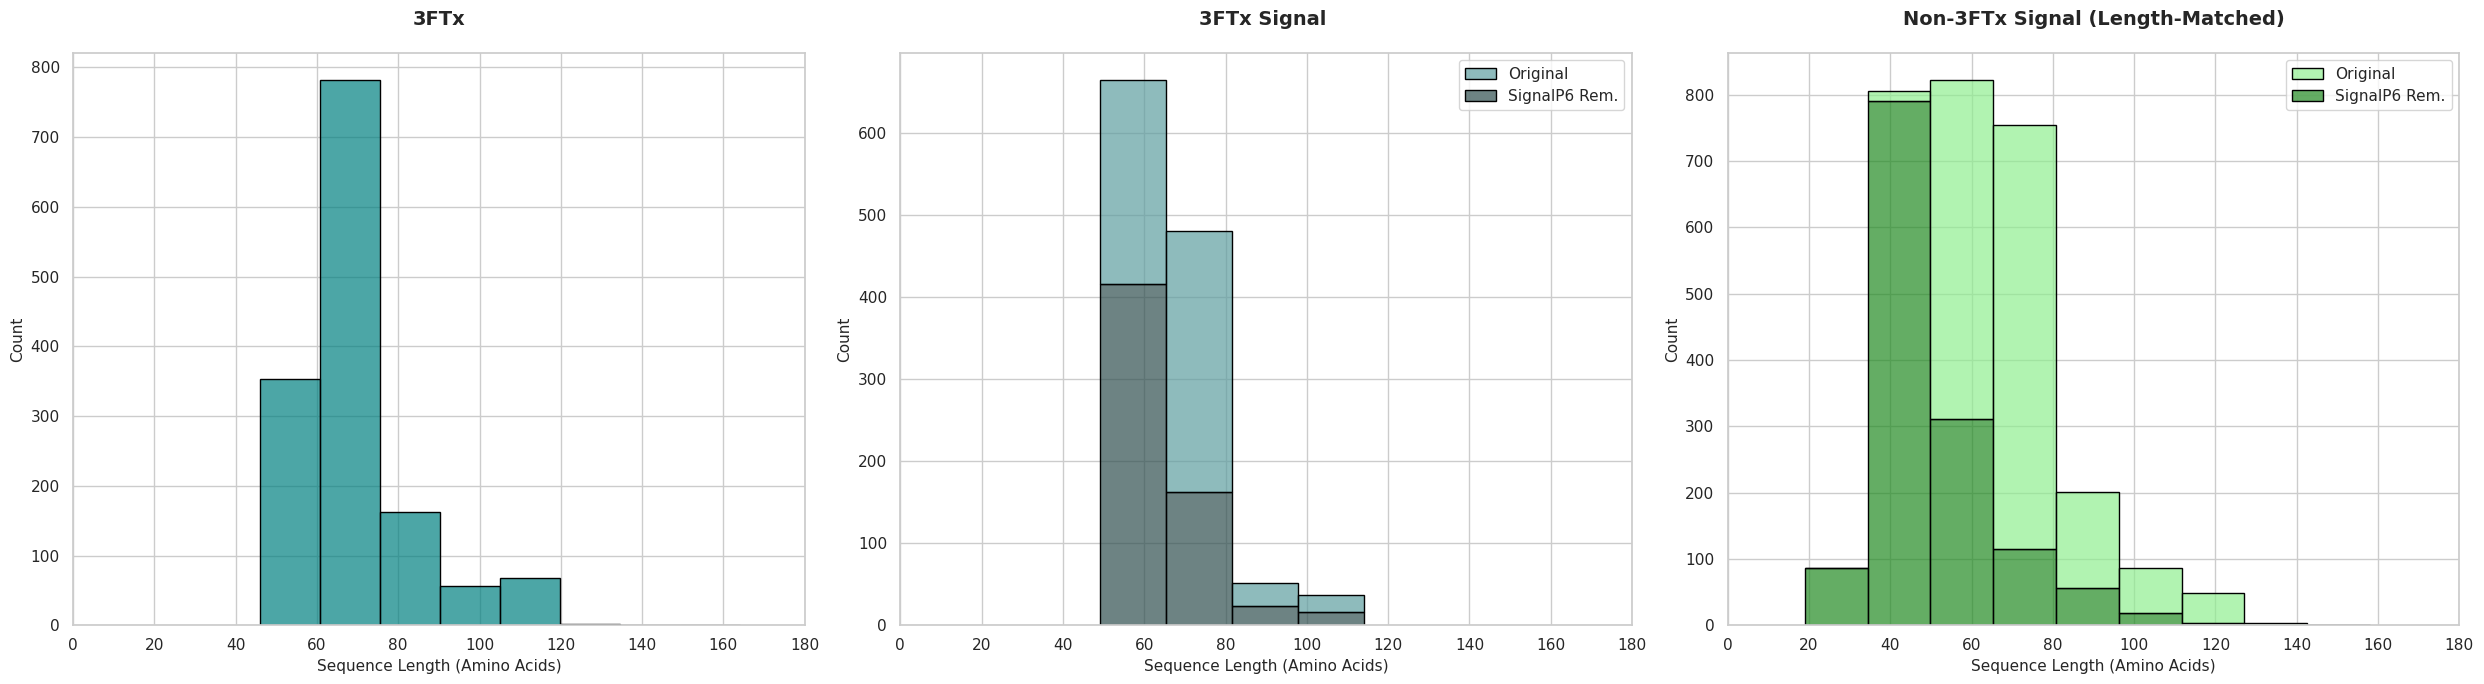

In [ ]:
    import os
    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

    # --- 1. Fixed Helper Function for FASTA Processing ---
    def get_fasta_records(fasta_path):
        """Parses a FASTA file tracking the absolute string tail for '_2' tags."""
        if not os.path.exists(fasta_path):
            print(f"Warning: File not found at {fasta_path}. Skipping.")
            return {}
        records = {}
        current_id = None
        current_seq = []
        with open(fasta_path, "r") as f:
            for line in f:
                line = line.strip()
                if line.startswith(">"):
                    if current_id is not None:
                        records[current_id] = len("".join(current_seq))
                    
                    header = line[1:]
                    is_removed = header.endswith("_2")
                    base_id = header.split()[0]
                    current_id = f"{base_id}_2" if is_removed else base_id
                    
                    current_seq = []
                else:
                    current_seq.append(line)
            if current_id is not None:
                records[current_id] = len("".join(current_seq))
        return records


    # --- 2. Load Datasets ---
    df_3ftx = pd.read_csv("datasets/3FTx_annotation.csv")
    lengths_3ftx = df_3ftx["mature_seq"].dropna().astype(str).str.len()

    fasta_3ftx_path = "datasets/3FTx_signal_signalp6_merged.fasta"
    records_3ftx = get_fasta_records(fasta_3ftx_path)

    len_3ftx_orig = []
    len_3ftx_rem = []
    for pid, length in records_3ftx.items():
        if pid.endswith("_2"):
            len_3ftx_rem.append(length)
        else:
            len_3ftx_orig.append(length)

    fasta_non3ftx_path = "datasets/non3FTx_signal_signalp6_merged_lengthmatched.fasta"
    records_non3ftx = get_fasta_records(fasta_non3ftx_path)

    len_non3ftx_orig = []
    len_non3ftx_rem = []
    for pid, length in records_non3ftx.items():
        if pid.endswith("_2"):
            len_non3ftx_rem.append(length)
        else:
            len_non3ftx_orig.append(length)


    # --- 3. Plotting Setup (1x3 Grid Layout) ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(25, 7))

    TITLE_CONFIG = {"fontsize": 14, "fontweight": "bold", "pad": 20}

    all_lengths = (
        list(lengths_3ftx) + 
        len_3ftx_orig + len_3ftx_rem + 
        len_non3ftx_orig + len_non3ftx_rem
    )
    max_len = max(all_lengths) if all_lengths else 120
    x_limit = (max_len // 15 + 2) * 15  

    # [Plot 1] CSV Annotation
    sns.histplot(x=lengths_3ftx, kde=False, color="teal", binwidth=15, ax=axes[0], edgecolor="black", alpha=0.7)
    axes[0].set_title("3FTx", **TITLE_CONFIG)
    axes[0].set_xlim(0, x_limit)

    # [Plot 2] 3FTx FASTA
    sns.histplot(
        data={"Original": len_3ftx_orig, "SignalP6 Rem.": len_3ftx_rem},
        multiple="stack", binwidth=15, kde=False,
        palette={"Original": "cadetblue", "SignalP6 Rem.": "darkslategrey"},
        edgecolor="black", alpha=0.7, ax=axes[1]
    )
    axes[1].set_title("3FTx Signal ", **TITLE_CONFIG)
    axes[1].set_xlim(0, x_limit)

    # [Plot 3] Non-3FTx FASTA (Now correctly tracking mixed arrays)
    sns.histplot(
        data={"Original": len_non3ftx_orig, "SignalP6 Rem.": len_non3ftx_rem},
        multiple="stack", binwidth=15, kde=False,
        palette={"Original": "lightgreen", "SignalP6 Rem.": "forestgreen"},
        edgecolor="black", alpha=0.7, ax=axes[2]
    )
    axes[2].set_title("Non-3FTx Signal (Length-Matched)", **TITLE_CONFIG)
    axes[2].set_xlim(0, x_limit)

    for ax in axes:
        ax.set_xlabel("Sequence Length (Amino Acids)", fontsize=11)
        ax.set_ylabel("Count", fontsize=11)

    plt.tight_layout()
    plt.show()

Reading dataset from datasets/uniref50_under_2k_subset.tsv...
Loaded 10,000 entries. Generating plot...


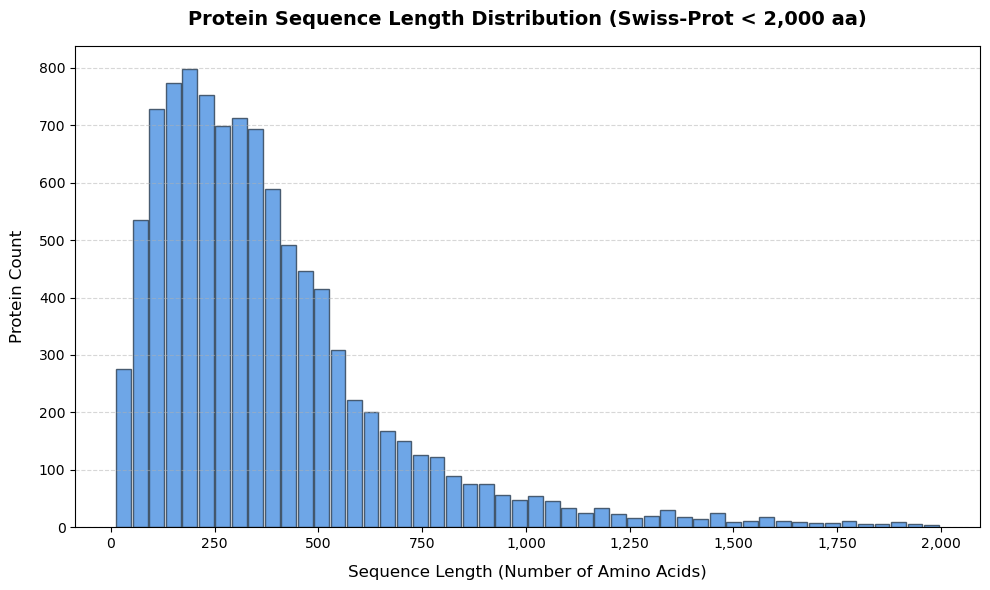

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define paths
input_file = "datasets/uniref50_under_2k_subset.tsv"


print(f"Reading dataset from {input_file}...")
if not os.path.exists(input_file):
    print(f"❌ Error: {input_file} not found. Please ensure your concatenation script ran successfully.")
    exit()

df = pd.read_csv(input_file, sep="\t")

# Ensure the Length column exists
if "Length" not in df.columns:
    print("❌ Error: 'Length' column not found in the file. Available columns:", df.columns.tolist())
    exit()

print(f"Loaded {len(df):,} entries. Generating plot...")

# 2. Setup the plot canvas using subplots (avoiding .figure())
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the histogram
# 50 bins provides an excellent granularity for sequences ranging from 0 to 2,000
n, bins, patches = ax.hist(
    df["Length"], 
    bins=50, 
    color="#4A90E2", 
    edgecolor="#2C3E50", 
    alpha=0.8, 
    rwidth=0.9
)

# 4. Refine layout, text labels, and ensure readability
ax.set_title("Protein Sequence Length Distribution (Swiss-Prot < 2,000 aa)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Sequence Length (Number of Amino Acids)", fontsize=12, labelpad=10)
ax.set_ylabel("Protein Count", fontsize=12, labelpad=10)

# Add a subtle grid on the Y-axis to help read counts easily
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Format axes numbers with commas for clean representation
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Adjust margins automatically to prevent text truncation
plt.tight_layout()

# 5. Save the final image to disk
plt.show()  # Display the plot for immediate feedback

plt.close()


In [3]:
import pandas as pd

input_file = "datasets/uniref50_under_2k.tsv"

try:
    df = pd.read_csv(input_file, sep="\t")
    
    max_len = df["Length"].max()
    min_len = df["Length"].min()
    avg_len = df["Length"].mean()
    
    print("=" * 40)
    print(f"📊 Sequence Length Stats for {input_file}")
    print("=" * 40)
    print(f"Maximum Length: {max_len:,} amino acids")
    print(f"Minimum Length: {min_len:,} amino acids")
    print(f"Average Length: {avg_len:.1f} amino acids")
    print("=" * 40)

except FileNotFoundError:
    print(f"❌ Error: '{input_file}' not found.")
except KeyError:
    print("❌ Error: Could not find 'Length' column in the file.")

📊 Sequence Length Stats for datasets/uniref50_under_2k.tsv
Maximum Length: 7,095 amino acids
Minimum Length: 11 amino acids
Average Length: 348.1 amino acids
